# 02 - Embedding Pipeline (Movies Final)

Mục tiêu:
1. Load dữ liệu đã qua EDA (`movies_final_for_embedding.csv`)
2. Chạy thử nhiều model embedding
3. Trực quan embedding space (PCA)
4. Test semantic search
5. Build ChromaDB index (prototype)

## I. Import + Config

In [4]:
# !pip install sentence_transformers chromadb
import os
import ast
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import chromadb

## II. Load dữ liệu và kiểm tra nhanh
Đọc file `movies_final.csv` từ thư mục processed. Đảm bảo dữ liệu đã có sẵn cột `rich_text` được tạo từ các bước Data Preparation trước đó.


In [5]:
DATA_PATH = "../backend/data/processed/movies_final.csv"  # Đã đổi tên file
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)


Shape: (35798, 11)
Columns: ['imdb_id', 'title', 'year', 'genres', 'runtime', 'rating', 'votes', 'director', 'cast', 'plots', 'rich_text']


,imdb_id,title,year,genres,runtime,rating,votes,director,cast,plots,rich_text
0,tt0035423,Kate & Leopold,2001.0,"['Comedy', 'Fantasy', 'Romance']",118.0,6.4,94017,James Mangold,"Meg Ryan, Hugh Jackman, Liev Schreiber",When her scientist ex-boyfriend discovers a po...,Title: Kate & Leopold (2001.0)\nGenres: ['Come...
1,tt0038687,Let There Be Light,1980.0,"['Documentary', 'War']",58.0,7.4,2178,NaN,Walter Huston,The final entry in a trilogy of films produced...,Title: Let There Be Light (1980.0)\nGenres: ['...
2,tt0062285,"Oh, Sun",1970.0,['Drama'],98.0,7.4,1088,Med Hondo,"Robert Liensol, Théo Légitimus, Ambroise M'Bia",An educated native of Mauritania tries to find...,"Title: Oh, Sun (1970.0)\nGenres: ['Drama']\nRa..."


In [6]:
required_cols = ["imdb_id", "title", "plots", "rich_text"]
for c in required_cols:
    assert c in df.columns, f"Thiếu cột bắt buộc: {c}"

print("Null rich_text:", df["rich_text"].isna().sum())
print("Duplicate imdb_id:", df["imdb_id"].astype(str).duplicated().sum())


Null rich_text: 0
Duplicate imdb_id: 0


## III. So sánh tốc độ model embedding
Lấy một sample nhỏ để test tốc độ encode của các model sentence-transformers khác nhau. Giúp ta cân nhắc sự đánh đổi giữa tốc độ và độ chính xác trước khi chạy cho toàn bộ tập dữ liệu.


In [7]:
sample_n = min(1000, len(df))
df_sample = df.sample(sample_n, random_state=42).copy()

models_to_test = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2",
]

benchmark = []
for model_name in models_to_test:
    model = SentenceTransformer(model_name)
    start = time.time()
    # Dùng cột rich_text đã có sẵn
    embs = model.encode(df_sample["rich_text"].tolist(), normalize_embeddings=True, show_progress_bar=False)
    elapsed = time.time() - start
    benchmark.append({
        "model": model_name,
        "seconds": round(elapsed, 2),
        "dim": int(embs.shape[1]),
        "rows": len(df_sample),
    })

pd.DataFrame(benchmark)


c:\Users\ADMIN\anaconda3\envs\movie_recommend\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1372.29it/s]
c:\Users\ADMIN\

,model,seconds,dim,rows
0,all-MiniLM-L6-v2,42.54,384,1000
1,all-mpnet-base-v2,226.31,768,1000


## IV. Chọn model chính và tạo embedding cho sample để trực quan
Sau khi xem xét tốc độ ở bước trên, chọn ra model phù hợp nhất. `all-MiniLM-L6-v2` thường là lựa chọn cân bằng tốt cho prototype do tốc độ siêu nhanh và chất lượng khá tốt.


In [8]:
MODEL_NAME = "all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)

sample_emb = model.encode(
    df_sample["rich_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

print("Sample embedding shape:", sample_emb.shape)


Batches: 100%|██████████| 32/32 [00:33<00:00,  1.06s/it]

Sample embedding shape: (1000, 384)


## V. PCA 2D để trực quan không gian Embedding
Sử dụng PCA (Principal Component Analysis) để giảm chiều dữ liệu embedding từ 384 chiều xuống 2 chiều. Trực quan hóa giúp ta xem các bộ phim có phân bố dạng cụm (clusters) hợp lý không.


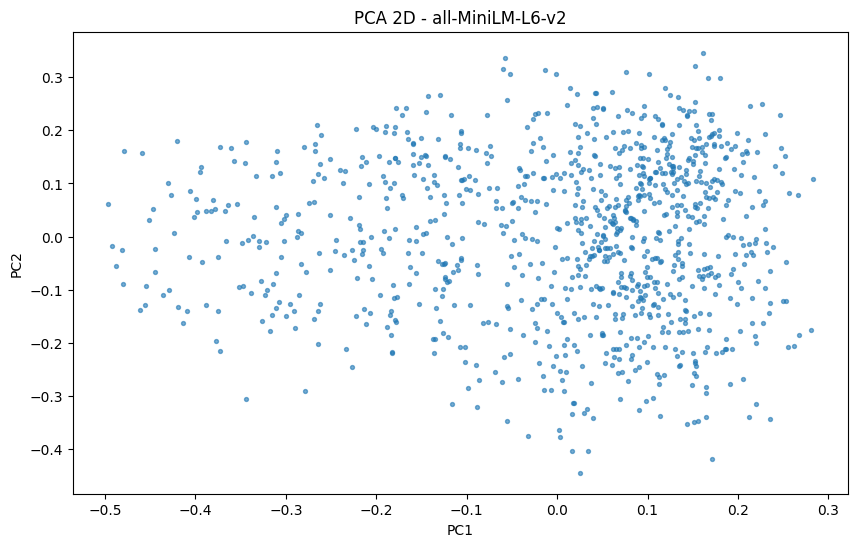

In [9]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(sample_emb)

df_sample["x"] = coords[:, 0]
df_sample["y"] = coords[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(df_sample["x"], df_sample["y"], s=8, alpha=0.6)
plt.title(f"PCA 2D - {MODEL_NAME}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Nhận xét: 

- Kết quả khá ổn khi không thấy các outlier bị cách quá xa

- Phân bố có 1 vùng dày bên phải và vùng thưa bên trái, cho thấy dữ liệu có vài cụm tự nhiên 

- Nên thử tô màu theo `genre` để xem các cụm này có ý nghĩa không? 

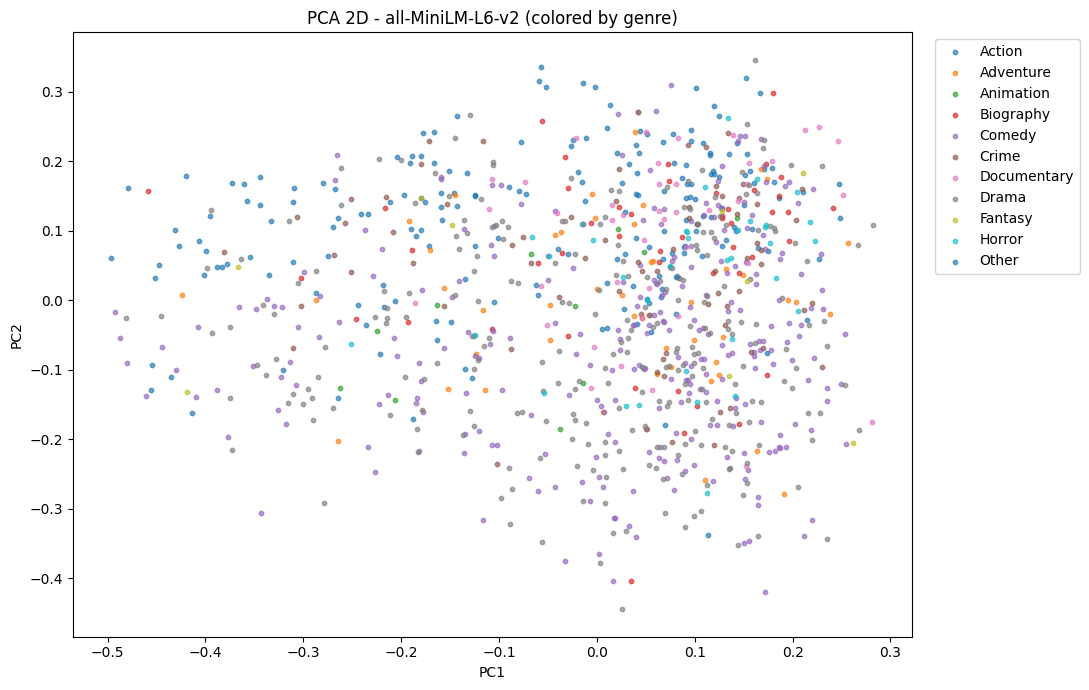

Explained variance ratio: [0.03829066 0.03035085] | Sum: 0.068641506


In [16]:
def parse_genres(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(i).strip() for i in v if str(i).strip()]
    except Exception:
        pass
    return [i.strip() for i in s.split(",") if i.strip()]

# cần cột genres trong df_sample
df_sample["genres_list"] = df_sample["genres"].apply(parse_genres)
df_sample["primary_genre"] = df_sample["genres_list"].apply(lambda g: g[0] if len(g) else "Unknown")

# gom top genre để legend không quá rối
top_k = 10
top_genres = df_sample["primary_genre"].value_counts().head(top_k).index
df_sample["genre_plot"] = np.where(df_sample["primary_genre"].isin(top_genres), df_sample["primary_genre"], "Other")

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(sample_emb)

df_sample["x"] = coords[:, 0]
df_sample["y"] = coords[:, 1]

plt.figure(figsize=(11, 7))
for g, sub in df_sample.groupby("genre_plot"):
    plt.scatter(sub["x"], sub["y"], s=10, alpha=0.65, label=g)

plt.title(f"PCA 2D - {MODEL_NAME} (colored by genre)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_, 
      "| Sum:", pca.explained_variance_ratio_.sum())

## VI. Test semantic search thủ công (cosine similarity)
Kiểm tra độ hiệu quả của model bằng cách tính toán Dot Product (tương đương Cosine Similarity do vector đã được normalize) giữa một query mẫu và toàn bộ vector trong sample.


In [19]:
import re
query = "A lonely person searching for meaning of life and time"
q_emb = model.encode([query], normalize_embeddings=True)

# 1) cosine score
base_scores = np.dot(sample_emb, q_emb.T).flatten()
cand = df_sample.copy()
cand["score_cosine"] = base_scores

# 2) (optional) filter nhẹ theo genre/rating nếu có
if "genres" in cand.columns:
    wanted = ["Drama", "Sci-Fi", "Romance"]
    cand = cand[cand["genres"].astype(str).str.contains("|".join(wanted), case=False, na=False)]

if "rating" in cand.columns:
    cand["rating"] = pd.to_numeric(cand["rating"], errors="coerce")
    cand = cand[(cand["rating"].isna()) | (cand["rating"] >= 6.0)]

# 3) keyword boost trên rich_text/plot
text_col = "rich_text" if "rich_text" in cand.columns else "plot"
kw = [
    "lonely", "loneliness", "isolation", "meaning of life",
    "existential", "time", "purpose", "identity"
]
pattern = re.compile("|".join([re.escape(k) for k in kw]), flags=re.IGNORECASE)

def kw_boost(text: str) -> float:
    if not isinstance(text, str):
        return 0.0
    hits = len(pattern.findall(text))
    return min(hits * 0.02, 0.10)  # max +0.10

cand["score_kw"] = cand[text_col].apply(kw_boost)
cand["score_final"] = cand["score_cosine"] + cand["score_kw"]

# 4) show top-k
top_k = 10
cols = ["title", "year", "genres", "score_cosine", "score_kw", "score_final"] if "genres" in cand.columns else ["title", "year", "score_cosine", "score_kw", "score_final"]
display(cand.nlargest(top_k, "score_final")[cols])


,title,year,genres,score_cosine,score_kw,score_final
23458,Fallen Leaves,2023.0,"['Comedy', 'Drama', 'Romance']",0.319843,0.02,0.339843
9038,Fly Me to Polaris,1999.0,"['Drama', 'Fantasy', 'Romance']",0.292361,0.02,0.312361
8470,Boredom,1998.0,"['Drama', 'Romance']",0.306411,0.00,0.306411
3242,The Home and the World,1984.0,['Drama'],0.287690,0.00,0.287690
13125,The Time Traveler's Wife,2009.0,"['Drama', 'Fantasy', 'Romance']",0.242181,0.04,0.282181
3635,Twice in a Lifetime,1985.0,"['Drama', 'Romance']",0.261347,0.02,0.281347
4998,Longtime Companion,1989.0,"['Drama', 'Romance']",0.258323,0.02,0.278323
11388,Shadows of Time,2004.0,"['Drama', 'Romance']",0.247646,0.02,0.267646
26785,New Life,2016.0,"['Drama', 'Romance']",0.267374,0.00,0.267374
22719,A Beautiful Life,2011.0,"['Drama', 'Romance']",0.266472,0.00,0.266472


## VII. Build Vector Database (ChromaDB) cho toàn bộ dữ liệu
Khởi tạo và lưu embedding vào ChromaDB để có thể truy vấn ngữ nghĩa cho backend sau này. Chúng ta sẽ lưu kèm các metadata (như title, year, director...) để hiển thị lúc trả kết quả mà không cần look-up DB khác.


In [22]:
CHROMA_PATH = "../backend/data/chromadb"
COLLECTION_NAME = "movies"

client = chromadb.PersistentClient(path=CHROMA_PATH)
# Xóa collection cũ nếu đang chạy lại để tránh trùng lặp
try:
    client.delete_collection(COLLECTION_NAME)
except:
    pass

collection = client.get_or_create_collection(
    name=COLLECTION_NAME,
    metadata={"hnsw:space": "cosine"}
)


## VII. Chạy Indexing Data vào ChromaDB
Do tập dữ liệu có thể lớn, ta sẽ thực hiện mã hoá (encode) và đẩy dữ liệu vào ChromaDB theo từng batch nhỏ (ví dụ: 256 record/batch) để tránh quá tải RAM.


In [23]:
batch_size = 256
df_prototype = df.head(2000).copy() 
n = len(df_prototype)

for i in range(0, n, batch_size):
    b = df_prototype.iloc[i:i+batch_size].copy()

    texts = b["rich_text"].fillna("").tolist()
    emb = model.encode(texts, normalize_embeddings=True, show_progress_bar=False)

    # Xử lý metadata an toàn cho ChromaDB
    metadatas = []
    for _, row in b.iterrows():
        metadatas.append({
            "title": str(row.get("title", "")),
            "year": float(row.get("year", 0)) if pd.notna(row.get("year")) else 0.0,
            "genres": str(row.get("genres", "")),
            "rating": float(row.get("rating", 0)) if pd.notna(row.get("rating")) else 0.0,
            "director": str(row.get("director", ""))
        })

    collection.add(
        ids=b["imdb_id"].astype(str).tolist(),
        embeddings=emb.tolist(),
        documents=texts,  # Lưu lại rich_text vào DB để tí nữa regex boost
        metadatas=metadatas
    )

    if (i // batch_size) % 10 == 0:
        print(f"Indexed {min(i+batch_size, n)}/{n}")

print("Done indexing ChromaDB.")


Indexed 256/2000
Done indexing ChromaDB.


## IX. Truy vấn thực tế (Hybrid Search) với ChromaDB
Áp dụng logic: Lấy Top 50 từ ChromaDB (Cosine) -> Filter cứng -> Keyword Boost -> Top 10 Final.


In [24]:
import re

query = "A lonely person searching for meaning of life and time"
q_emb = model.encode([query], normalize_embeddings=True)

# 1. RETRIEVER: Lấy Top 50 từ VectorDB
raw_results = collection.query(
    query_embeddings=q_emb.tolist(),
    n_results=50,  
    include=["metadatas", "distances", "documents"]
)

# Chuyển kết quả ChromaDB sang DataFrame để dễ xử lý 
retrieved_df = pd.DataFrame(raw_results["metadatas"][0])
retrieved_df["score_cosine"] = [1 - d for d in raw_results["distances"][0]] # Convert distance to similarity
retrieved_df["rich_text"] = raw_results["documents"][0]

# 2. RERANKER
cand = retrieved_df.copy()

# Filter Genres
wanted = ["Drama", "Sci-Fi", "Romance"]
cand = cand[cand["genres"].str.contains("|".join(wanted), case=False, na=False)]

# Filter Rating
cand = cand[(cand["rating"].isna()) | (cand["rating"] >= 6.0)]

# Keyword Boost
kw = ["lonely", "loneliness", "isolation", "meaning of life", "existential", "time", "purpose", "identity"]
pattern = re.compile("|".join([re.escape(k) for k in kw]), flags=re.IGNORECASE)

def kw_boost(text: str) -> float:
    if not isinstance(text, str): return 0.0
    hits = len(pattern.findall(text))
    return min(hits * 0.02, 0.10)

cand["score_kw"] = cand["rich_text"].apply(kw_boost)
cand["score_final"] = cand["score_cosine"] + cand["score_kw"]

# Hiển thị Top 10 cuối cùng
cols = ["title", "year", "genres", "rating", "score_cosine", "score_kw", "score_final"]
display(cand.nlargest(10, "score_final")[cols])


,title,year,genres,rating,score_cosine,score_kw,score_final
0,Footprints on the Moon,1975.0,"['Drama', 'Horror', 'Mystery']",6.6,0.303401,0.00,0.303401
1,Being There,1979.0,"['Comedy', 'Drama']",7.9,0.294978,0.00,0.294978
18,Beg,1971.0,"['Drama', 'History', 'War']",7.7,0.233969,0.06,0.293969
2,Still Life,1974.0,['Drama'],7.6,0.263967,0.02,0.283967
10,Twenty Days Without War,1977.0,"['Drama', 'Romance', 'War']",7.7,0.246290,0.02,0.266290
11,"Jeanne Dielman, 23, quai du Commerce, 1080 Bru...",1975.0,['Drama'],7.5,0.245163,0.02,0.265163
3,"A Reason to Live, a Reason to Die",1972.0,"['Drama', 'Western']",6.1,0.259236,0.00,0.259236
17,Benji,1974.0,"['Adventure', 'Drama', 'Family']",6.1,0.234843,0.02,0.254843
4,The Wishing Tree,1976.0,['Drama'],8.0,0.253577,0.00,0.253577
5,On a Clear Day You Can See Forever,1970.0,"['Comedy', 'Drama', 'Fantasy']",6.4,0.251999,0.00,0.251999


In [25]:
print("Chroma persisted at:", CHROMA_PATH)
print("Sẵn sàng mang logic Hybrid Search sang API Backend!")


Chroma persisted at: ../backend/data/chromadb
Sẵn sàng mang logic Hybrid Search sang API Backend!
